In [ ]:
import pandas as pd
import numpy as np
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from itertools import product 
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=ConvergenceWarning)

df = pd.read_csv("df_hmm.csv", parse_dates=["date"])

df_clean = df.dropna(subset=['hmm_regime', 'hmm_prob_high_t1']).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"\nRegime distribution:")
print(df['hmm_regime'].value_counts().sort_index())

Dataset shape: (3489, 49)

Regime distribution:
hmm_regime
0.0    1975
1.0    1149
Name: count, dtype: int64


In [57]:
svr_features = [
    "log_return",
    "gtrend_pct_change",
    "blockchain_diff_log_n_transactions",
    "blockchain_diff_log_transaction_fee_usd",
    "blockchain_diff_log_n_unique_addresses",
    "blockchain_diff_log_transaction_volume_usd",
    "log_volume",
    "gold_close_ret",
    "silver_close_ret",
    "brent_close_ret",
    "dji_close_ret",
    "spx_close_ret",
    "rut_close_ret",
    "nasdaq_close_ret",
    "usdcny_close_ret",
    "usdeur_close_ret",
    "gold_volume_chg",
    "silver_volume_chg",
    "brent_volume_chg",
    "dji_volume_chg",
    "spx_volume_chg",
    "rut_volume_chg",
    "nasdaq_volume_chg",
    "vix_close_chg",
    "hash-rate_chg",
    "difficulty_chg",
    "median-confirmation-time_chg",
    "blockchain_log_mempool_count_chg",
    "rvar_7",
    "rvar_30",
    "rvar_lag1",
    "rvar_lag2",
    "rvar_lag3",
    "hmm_prob_high_t1"
]
print(f"\nTotal SVR features: {len(svr_features)}")
print(svr_features)


Total SVR features: 34
['log_return', 'gtrend_pct_change', 'blockchain_diff_log_n_transactions', 'blockchain_diff_log_transaction_fee_usd', 'blockchain_diff_log_n_unique_addresses', 'blockchain_diff_log_transaction_volume_usd', 'log_volume', 'gold_close_ret', 'silver_close_ret', 'brent_close_ret', 'dji_close_ret', 'spx_close_ret', 'rut_close_ret', 'nasdaq_close_ret', 'usdcny_close_ret', 'usdeur_close_ret', 'gold_volume_chg', 'silver_volume_chg', 'brent_volume_chg', 'dji_volume_chg', 'spx_volume_chg', 'rut_volume_chg', 'nasdaq_volume_chg', 'vix_close_chg', 'hash-rate_chg', 'difficulty_chg', 'median-confirmation-time_chg', 'blockchain_log_mempool_count_chg', 'rvar_7', 'rvar_30', 'rvar_lag1', 'rvar_lag2', 'rvar_lag3', 'hmm_prob_high_t1']


In [58]:
# Define clipping 
# floor: rolling mean 5 for predicted variance
#df_clean["var_floor_5"] = df_clean["target_var"].shift(1).rolling(5, min_periods=5).mean()
# global upper bound
upper_bound = df_clean["target_var"].quantile(0.995)

#def clip_variance_pred(pred, floor_val, upper_bound):
#    if pd.isna(floor_val):
#        floor_val = 1e-8
#    else:
#        floor_val = max(1e-8, floor_val)
#    return np.clip(pred, floor_val, upper_bound)

In [59]:
# 60/25/15 split
total_len = len(df_clean)
train_size = int(total_len * 0.60)
val_size = int(total_len * 0.25)

train_end = train_size
val_start = train_size
val_end = train_size + val_size
test_start = val_end

print(f"Train: {0:4d} to {train_end:4d} ({train_size:4d} days) | {df_clean['date'].iloc[0]} to {df_clean['date'].iloc[train_end-1]}")
print(f"Val:   {val_start:4d} to {val_end:4d} ({val_size:4d} days) | {df_clean['date'].iloc[val_start]} to {df_clean['date'].iloc[val_end-1]}")
print(f"Test:  {test_start:4d} to {total_len:4d} ({total_len - test_start:4d} days) | {df_clean['date'].iloc[test_start]} to {df_clean['date'].iloc[-1]}")

window_size = 365

Train:    0 to 1873 (1873 days) | 2017-07-14 00:00:00 to 2022-08-29 00:00:00
Val:   1873 to 2653 ( 780 days) | 2022-08-30 00:00:00 to 2024-10-17 00:00:00
Test:  2653 to 3123 ( 470 days) | 2024-10-18 00:00:00 to 2026-01-30 00:00:00


In [60]:
# Grid search for C and epsilon
C_values = [0.1, 1.0, 10.0]
epsilon_values = [0.0001, 0.001, 0.01]

val_sample_indices = range(val_start, val_end, 5)
valid_indices = [i for i in val_sample_indices if i >= window_size]
grid_results = []
total_configs = len(C_values) * len(epsilon_values)

print(f"Testing {total_configs} configurations on {len(valid_indices)} samples...")
print(f"Total features: {len(svr_features)}")
print(f"Window size: {window_size} days")

config_num = 0

for C, epsilon in product(C_values, epsilon_values):
    config_num += 1
    
    preds = []
    actuals = []
    
    for i in valid_indices:
        train_X = df_clean.iloc[i - window_size : i][svr_features].values
        train_y = df_clean.iloc[i - window_size : i]['target_var'].values
        
        test_X = df_clean.iloc[i:i+1][svr_features].values
        target_val = df_clean.iloc[i]['target_var']
        
        try:
            # Scale features AND target
            scaler_X = StandardScaler()
            scaler_y = StandardScaler()
            
            train_X_scaled = scaler_X.fit_transform(train_X)
            train_y_scaled = scaler_y.fit_transform(train_y.reshape(-1, 1)).ravel()
            test_X_scaled = scaler_X.transform(test_X)
            
            # Fit SVR with current hyperparameters
            model = SVR(kernel='linear', C=C, epsilon=epsilon, max_iter=1000)  # Add max_iter
            model.fit(train_X_scaled, train_y_scaled)
            
            # Predict and inverse transform
            pred_scaled = model.predict(test_X_scaled)[0]
            pred = scaler_y.inverse_transform([[pred_scaled]])[0, 0]
            
            #clip
            pred = np.clip(pred, 1e-7, upper_bound)
            
            preds.append(pred)
            actuals.append(target_val)
            
        except Exception as e:
            fallback = preds[-1] if preds else 0
            preds.append(fallback)
            actuals.append(target_val)
    
    if len(preds) > 0:
        rmse = np.sqrt(mean_squared_error(actuals, preds))
        grid_results.append({'C': C, 'epsilon': epsilon, 'RMSE': rmse})

    print(f"Config {config_num}/{total_configs}: C={C:6.1f}, ε={epsilon:5.3f}, RMSE={rmse:.8f} | ")

results_df = pd.DataFrame(grid_results).sort_values('RMSE')

print("\n" + "="*60)
print("TOP 10 CONFIGURATIONS")
print("="*60)
print(results_df.head(10).to_string(index=False))

best_config = results_df.iloc[0]
best_C = best_config['C']
best_epsilon = best_config['epsilon']

print(f"\n" + "="*60)
print("BEST CONFIGURATION")
print("="*60)
print(f"C:       {best_C}")
print(f"epsilon: {best_epsilon}")
print(f"Validation RMSE: {best_config['RMSE']:.8f}") 
print("="*60)

Testing 9 configurations on 156 samples...
Total features: 34
Window size: 365 days


Config 1/9: C=   0.1, ε=0.000, RMSE=0.00095766 | 
Config 2/9: C=   0.1, ε=0.001, RMSE=0.00095139 | 
Config 3/9: C=   0.1, ε=0.010, RMSE=0.00095371 | 
Config 4/9: C=   1.0, ε=0.000, RMSE=0.00108876 | 
Config 5/9: C=   1.0, ε=0.001, RMSE=0.00099685 | 
Config 6/9: C=   1.0, ε=0.010, RMSE=0.00099812 | 
Config 7/9: C=  10.0, ε=0.000, RMSE=0.00131620 | 
Config 8/9: C=  10.0, ε=0.001, RMSE=0.00117171 | 
Config 9/9: C=  10.0, ε=0.010, RMSE=0.00123225 | 

TOP 10 CONFIGURATIONS
   C  epsilon     RMSE
 0.1   0.0010 0.000951
 0.1   0.0100 0.000954
 0.1   0.0001 0.000958
 1.0   0.0010 0.000997
 1.0   0.0100 0.000998
 1.0   0.0001 0.001089
10.0   0.0010 0.001172
10.0   0.0100 0.001232
10.0   0.0001 0.001316

BEST CONFIGURATION
C:       0.1
epsilon: 0.001
Validation RMSE: 0.00095139


In [61]:
#best_C = 0.1
#best_epsilon = 0.0001

In [62]:
val_preds = []
val_actuals = []
val_dates = []
failures = 0

print(f"\nRunning full validation with C={best_C}, epsilon={best_epsilon}...")

for i in range(val_start, val_end):
    if i < window_size:
        continue
    
    train_X = df_clean.iloc[i - window_size : i][svr_features].values
    train_y = df_clean.iloc[i - window_size : i]['target_var'].values
    
    test_X = df_clean.iloc[i:i+1][svr_features].values
    target_val = df_clean.iloc[i]['target_var']
    current_date = df_clean.iloc[i]['date']
    
    try:
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()
        
        train_X_scaled = scaler_X.fit_transform(train_X)
        train_y_scaled = scaler_y.fit_transform(train_y.reshape(-1, 1)).ravel()
        test_X_scaled = scaler_X.transform(test_X)
        
        model = SVR(kernel='linear', C=best_C, epsilon=best_epsilon)
        model.fit(train_X_scaled, train_y_scaled)
        
        pred_scaled = model.predict(test_X_scaled)[0]
        pred = scaler_y.inverse_transform([[pred_scaled]])[0, 0]
        #clip
        pred = np.clip(pred, 1e-7, upper_bound)
        
        val_preds.append(pred)
        val_actuals.append(target_val)
        val_dates.append(current_date)
        
    except:
        failures += 1
        fallback = val_preds[-1] if val_preds else 0
        val_preds.append(fallback)
        val_actuals.append(target_val)
        val_dates.append(current_date)


Running full validation with C=0.1, epsilon=0.001...


In [63]:
val_preds = np.array(val_preds)
val_actuals = np.array(val_actuals)

val_rmse = np.sqrt(mean_squared_error(val_actuals, val_preds))
val_mae = mean_absolute_error(val_actuals, val_preds)
val_qlike = np.mean(val_actuals / (val_preds + 1e-10) - np.log(val_actuals / (val_preds + 1e-10)) - 1)


print(f"\n--- VALIDATION RESULTS ---")
print(f"RMSE:  {val_rmse:.6f}")
print(f"MAE:   {val_mae:.6f}")
print(f"QLIKE:   {val_qlike:.6f}")
print(f"Failures: {failures}")
print(f"Samples: {len(val_preds)}")


--- VALIDATION RESULTS ---
RMSE:  0.000877
MAE:   0.000443
QLIKE:   57.492870
Failures: 0
Samples: 780


In [64]:
test_preds = []
test_actuals = []
test_dates = []
failures_test = 0

print(f"\nRunning test set evaluation...")

for i in range(test_start, total_len):
    if i < window_size:
        continue
    
    train_X = df_clean.iloc[i - window_size : i][svr_features].values
    train_y = df_clean.iloc[i - window_size : i]['target_var'].values
    
    test_X = df_clean.iloc[i:i+1][svr_features].values
    target_val = df_clean.iloc[i]['target_var']
    current_date = df_clean.iloc[i]['date']
    
    try:
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()
        
        train_X_scaled = scaler_X.fit_transform(train_X)
        train_y_scaled = scaler_y.fit_transform(train_y.reshape(-1, 1)).ravel()
        test_X_scaled = scaler_X.transform(test_X)
        
        model = SVR(kernel='linear', C=best_C, epsilon=best_epsilon)
        model.fit(train_X_scaled, train_y_scaled)
        
        pred_scaled = model.predict(test_X_scaled)[0]
        pred = scaler_y.inverse_transform([[pred_scaled]])[0, 0]
        #clip
        pred = np.clip(pred, 1e-7, upper_bound)
        
        test_preds.append(pred)
        test_actuals.append(target_val)
        test_dates.append(current_date)
        
    except:
        failures_test += 1
        fallback = test_preds[-1] if test_preds else 0
        test_preds.append(fallback)
        test_actuals.append(target_val)
        test_dates.append(current_date)


Running test set evaluation...


In [65]:
test_preds = np.array(test_preds)
test_actuals = np.array(test_actuals)

test_rmse = np.sqrt(mean_squared_error(test_actuals, test_preds))
test_mae = mean_absolute_error(test_actuals, test_preds)
test_qlike = np.mean(test_actuals / (test_preds + 1e-10) - np.log(test_actuals / (test_preds + 1e-10)) - 1)

print(f"\n--- TEST RESULTS ---")
print(f"RMSE:  {test_rmse:.6f}")
print(f"MAE:   {test_mae:.6f}")
print(f"QLIKE:   {test_qlike:.6f}")
print(f"Failures: {failures_test}")
print(f"Samples: {len(test_preds)}")


--- TEST RESULTS ---
RMSE:  0.000631
MAE:   0.000359
QLIKE:   39.188118
Failures: 0
Samples: 470


In [66]:
summary = pd.DataFrame({
    'Dataset': ['Validation', 'Test'],
    'RMSE': [val_rmse, test_rmse],
    'MAE': [val_mae, test_mae],
    'QLIKE': [val_qlike,test_qlike],
    'Samples': [len(val_preds), len(test_preds)]
})

print("\n" + "="*60)
print("HMM-SVR-L Summary")
print("="*60)
print(summary.to_string(index=False))
print("="*60)
print(f"\nBest Parameters Used:")
print(f"  C: {best_C}")
print(f"  epsilon: {best_epsilon}")
print(f"  Features: {len(svr_features)}")
print("="*60)



HMM-SVR-L Summary
   Dataset     RMSE      MAE     QLIKE  Samples
Validation 0.000877 0.000443 57.492870      780
      Test 0.000631 0.000359 39.188118      470

Best Parameters Used:
  C: 0.1
  epsilon: 0.001
  Features: 34


In [67]:
results_df = pd.DataFrame({
    "date": test_dates,
    "actual_var": test_actuals,
    "pred_var": test_preds
})

results_df["error"] = results_df["actual_var"] - results_df["pred_var"]
results_df["abs_error"] = np.abs(results_df["error"])

results_df.to_csv("results/hmm_svrl_results.csv", index=False)

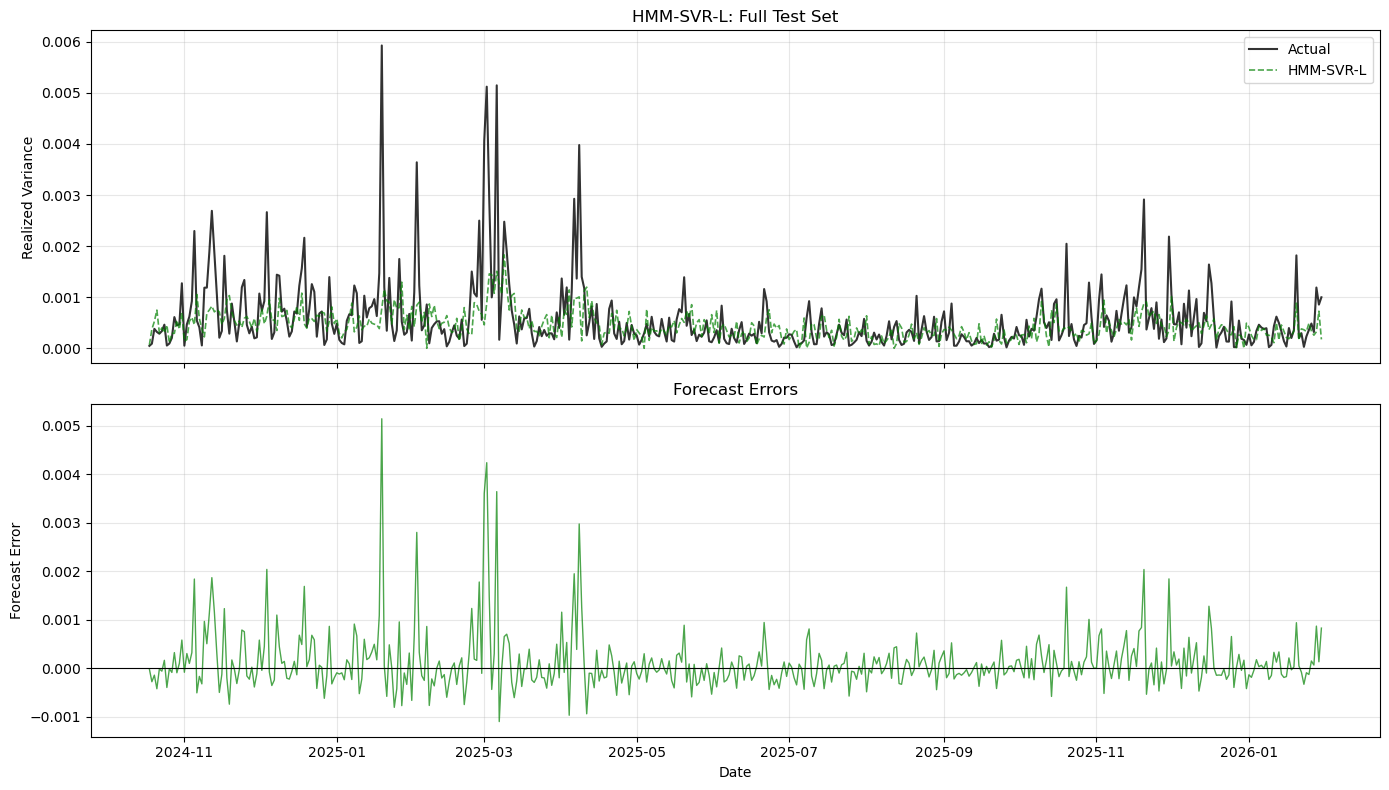

In [68]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

plot_n = len(test_actuals)
plot_dates = test_dates[-plot_n:]
plot_actuals = test_actuals[-plot_n:]
plot_forecasts = test_preds[-plot_n:]

# Panel 1: Actual vs Forecast
axes[0].plot(plot_dates, plot_actuals, label='Actual', color='black', linewidth=1.5, alpha=0.8)
axes[0].plot(plot_dates, plot_forecasts, label='HMM-SVR-L', color='green', linewidth=1.2, alpha=0.7, linestyle='--')
axes[0].set_ylabel('Realized Variance')
axes[0].set_title(f'HMM-SVR-L: Full Test Set')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Panel 2: Forecast Errors
errors = plot_actuals - plot_forecasts
axes[1].plot(plot_dates, errors, color='green', linewidth=1, alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1].set_ylabel('Forecast Error')
axes[1].set_xlabel('Date')
axes[1].set_title('Forecast Errors')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

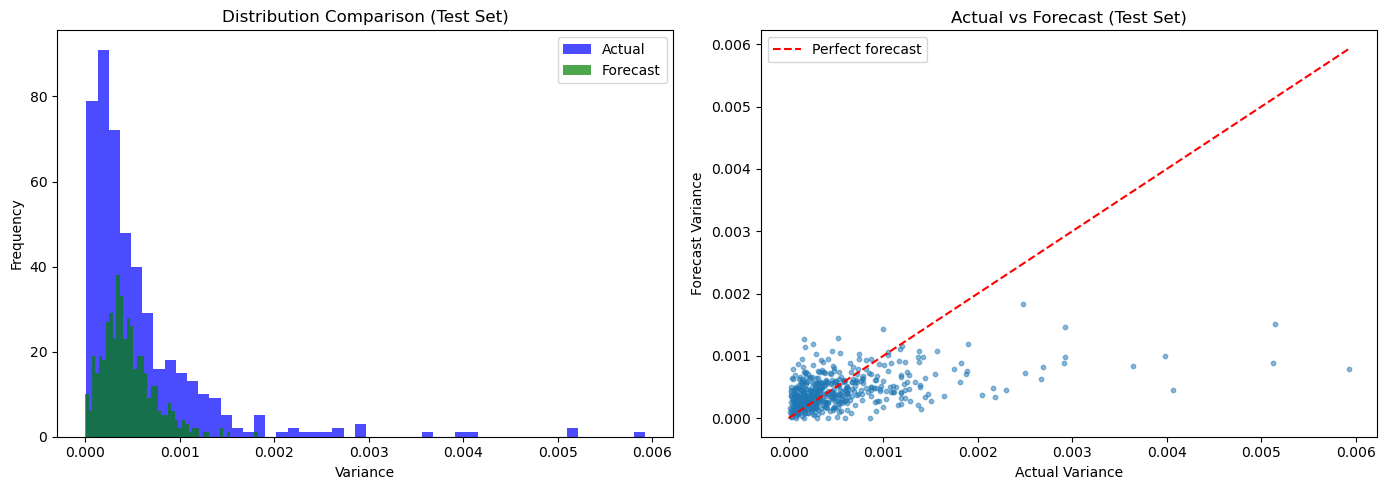


Forecast Statistics (Test Set):
  Mean forecast: 0.000449
  Mean actual:   0.000570
  Forecast std:  0.000273
  Actual std:    0.000689
  Forecasts > Actuals: 50.2%


In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution comparison
axes[0].hist(test_actuals, bins=50, alpha=0.7, label='Actual', color='blue')
axes[0].hist(test_preds, bins=50, alpha=0.7, label='Forecast', color='green')
axes[0].set_xlabel('Variance')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution Comparison (Test Set)')
axes[0].legend()

# Actual vs Forecast scatter
axes[1].scatter(test_actuals, test_preds, alpha=0.5, s=10)
axes[1].plot([0, test_actuals.max()], [0, test_actuals.max()], 'r--', label='Perfect forecast')
axes[1].set_xlabel('Actual Variance')
axes[1].set_ylabel('Forecast Variance')
axes[1].set_title('Actual vs Forecast (Test Set)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nForecast Statistics (Test Set):")
print(f"  Mean forecast: {test_preds.mean():.6f}")
print(f"  Mean actual:   {test_actuals.mean():.6f}")
print(f"  Forecast std:  {test_preds.std():.6f}")
print(f"  Actual std:    {test_actuals.std():.6f}")
print(f"  Forecasts > Actuals: {(test_preds > test_actuals).mean()*100:.1f}%")

In [70]:
pred_var = np.maximum(test_preds, 1e-10)
actual_var = np.maximum(test_actuals, 1e-10)
qlike_i = actual_var / pred_var - np.log(actual_var / pred_var) - 1

print("Mean QLIKE:", np.mean(qlike_i))
print("Median QLIKE:", np.median(qlike_i))
print("Max QLIKE:", np.max(qlike_i))

qlike_df = pd.DataFrame({
    "date": test_dates,
    "actual_var": actual_var,
    "pred_var": pred_var,
    "qlike": qlike_i
}).sort_values("qlike", ascending=False)

print(qlike_df.head(10))
print("Share pred < 1e-8:", np.mean(pred_var < 1e-8))
print("Share pred < 1e-7:", np.mean(pred_var < 1e-7))
print("Share pred < 1e-6:", np.mean(pred_var < 1e-6))

Mean QLIKE: 39.2266825978142
Median QLIKE: 0.19341026211896584
Max QLIKE: 8573.004886998273
          date  actual_var      pred_var        qlike
111 2025-02-06    0.000858  1.000000e-07  8573.004887
298 2025-08-12    0.000417  1.000000e-07  4158.588248
198 2025-05-04    0.000296  1.000000e-07  2948.678697
438 2025-12-30    0.000163  1.000000e-07  1618.794387
260 2025-07-05    0.000081  1.000000e-07   803.093908
263 2025-07-08    0.000591  5.657230e-06    98.877018
360 2025-10-13    0.000511  2.795146e-05    14.363554
173 2025-04-09    0.001399  1.441418e-04     6.432664
134 2025-03-01    0.004062  4.589944e-04     5.669267
264 2025-07-09    0.000923  1.155635e-04     4.906073
Share pred < 1e-8: 0.0
Share pred < 1e-7: 0.0
Share pred < 1e-6: 0.010638297872340425
